In [1]:
import json
import os
import pandas as pd
root = "/home/jovyan/myenvs/FBF/classification_frames"
files = {
    "train": f"{root}/annotations_train.json",
    "val":   f"{root}/annotations_val.json",
    "test":  f"{root}/annotations_test.json"
}

data_raw = {}

for split, path in files.items():
    print(f"Loading: {path}")
    with open(path, "r") as f:
        data_raw[split] = json.load(f)

first_split = list(data_raw.keys())[0]
first_key = next(iter(data_raw[first_split]))

print("\nExample Entry:")
print("image_path:", first_key)
print("annotation:", data_raw[first_split][first_key])


Loading: /home/jovyan/myenvs/FBF/classification_frames/annotations_train.json
Loading: /home/jovyan/myenvs/FBF/classification_frames/annotations_val.json
Loading: /home/jovyan/myenvs/FBF/classification_frames/annotations_test.json

Example Entry:
image_path: ./classification_frames/P1043127_720/frame461.jpg
annotation: {'driver_state': 'alert', 'landmarks': [[49, 122], [154, 127], [88, 183], [54, 241], [136, 243]]}


In [2]:
import json
import pandas as pd

all_path = "/home/jovyan/myenvs/FBF/classification_frames/annotations_all.json"

if not os.path.exists(all_path):
    raise FileNotFoundError("annotations_all.json غير موجود! تأكد من مسار الملف.")

print("Loading ALL data...")
with open(all_path, "r") as f:
    all_data = json.load(f)

print(f"✅ تم تحميل {len(all_data)} إطارًا من annotations_all.json")

Loading ALL data...
✅ تم تحميل 53331 إطارًا من annotations_all.json


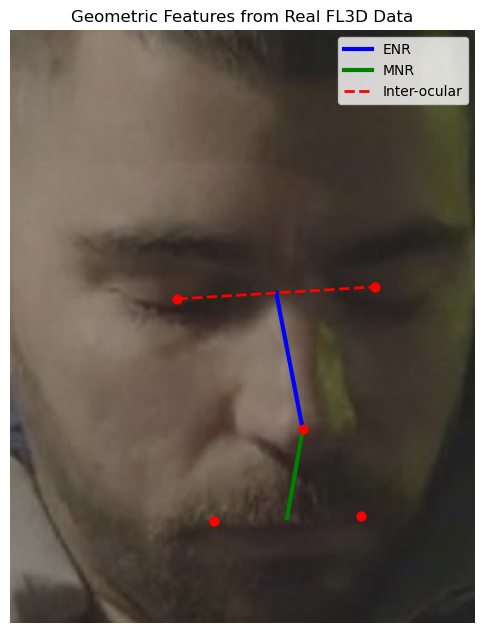

In [6]:
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# === 1. تحميل البيانات ===
ANNOT_PATH = "/home/jovyan/myenvs/FBF/classification_frames/annotations_all.json"
IMG_ROOT = "/home/jovyan/myenvs/FBF"  # لأن المسار في JSON يبدأ بـ ./classification_frames/...

with open(ANNOT_PATH, 'r') as f:
    annotations = json.load(f)

# === 2. اختيار إطار Microsleep ===
microsleep_frames = [
    fname for fname, data in annotations.items() 
    if data['driver_state'] == 'microsleep'  # لاحظ: الصغيرة 'm'
]

# تأكد من وجود حالات Microsleep
if not microsleep_frames:
    # جرب بحثًا غير حساس لحالة الأحرف
    microsleep_frames = [
        fname for fname, data in annotations.items() 
        if data['driver_state'].lower() == 'microsleep'
    ]

sample_frame_key = microsleep_frames[0]  # مثال: "./classification_frames/P1043127_720/frame461.jpg"

# استخراج مسار الصورة الفعلي
img_path = os.path.join(IMG_ROOT, sample_frame_key.replace('./', ''))

# === 3. تحميل الصورة والنقاط ===
img = Image.open(img_path)
landmarks = annotations[sample_frame_key]['landmarks']
lmks = np.array(landmarks)  # شكل: (5, 2)

# === 4. تحديد النقاط (بناءً على ترتيبك) ===
# من المثال: [[49,122], [154,127], [88,183], [54,241], [136,243]]
# نفترض الترتيب هو:
left_eye = lmks[0]      # [49, 122]
right_eye = lmks[1]     # [154, 127]
nose = lmks[2]          # [88, 183]
mouth_left = lmks[3]    # [54, 241]
mouth_right = lmks[4]   # [136, 243]

# حساب المراكز
c_eye = (left_eye + right_eye) / 2
c_mouth = (mouth_left + mouth_right) / 2

# === 5. الرسم ===
plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.scatter(lmks[:, 0], lmks[:, 1], s=40, c='red', zorder=5)

# رسم الخطوط
plt.plot([c_eye[0], nose[0]], [c_eye[1], nose[1]], 'b-', linewidth=3, label='ENR')
plt.plot([c_mouth[0], nose[0]], [c_mouth[1], nose[1]], 'g-', linewidth=3, label='MNR')
plt.plot([left_eye[0], right_eye[0]], [left_eye[1], right_eye[1]], 'r--', linewidth=2, label='Inter-ocular')

plt.legend(loc='upper right')
plt.axis('off')
plt.title("Geometric Features from Real FL3D Data", fontsize=12)
plt.savefig("enr_mnr_real.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd
import os
import numpy as np

# ===============================
# 1. بناء الـ DataFrame من البيانات الأصلية
# ===============================
rows = []
base_input = "/home/jovyan/myenvs/FBF/classification_frames-level-driver-drowsiness-detection-fl3d"

for img_path, info in all_data.items():
    parts = img_path.split("/")
    video_id = parts[-2]
    frame_str = os.path.splitext(parts[-1])[0]

    # رقم الإطار
    frame_num = None
    if frame_str.startswith("frame"):
        try:
            frame_num = int(frame_str.replace("frame", ""))
        except ValueError:
            pass  # إذا فشل التحويل، يبقى None

    # استخراج person_id من video_id (مثل: P1042751_720 → 1042751)
    person_id = None
    try:
        person_id = int(video_id.split("_")[0].replace("P", ""))
    except (ValueError, IndexError):
        pass  # إذا فشل الاستخراج، يبقى None

    full_img_path = os.path.join(base_input, img_path.lstrip("./"))

    rows.append({
        "image_path": full_img_path,
        "driver_state": info.get("driver_state"),
        "landmarks": info.get("landmarks"),
        "video_id": video_id,
        "frame": frame_str,
        "frame_num": frame_num,
        "person_id": person_id  # ← هذا هو الاسم الرسمي في FL3D
    })

# إنشاء الـ DataFrame
df = pd.DataFrame(rows)

# التحقق من البيانات
print("Total frames:", len(df))
print("Number of unique videos:", df["video_id"].nunique())
print("Number of unique person_id (sessions):", df["person_id"].nunique())

# عرض عينة
print("\nSample of the data:")
print(df.head())



Total frames: 53331
Number of unique videos: 44
Number of unique person_id (sessions): 44

Sample of the data:
                                          image_path driver_state  \
0  /home/jovyan/myenvs/FBF/classification_frames-...        alert   
1  /home/jovyan/myenvs/FBF/classification_frames-...        alert   
2  /home/jovyan/myenvs/FBF/classification_frames-...        alert   
3  /home/jovyan/myenvs/FBF/classification_frames-...        alert   
4  /home/jovyan/myenvs/FBF/classification_frames-...        alert   

                                           landmarks      video_id     frame  \
0  [[49, 122], [154, 127], [88, 183], [54, 241], ...  P1043127_720  frame461   
1  [[47, 122], [146, 125], [81, 175], [50, 238], ...  P1043127_720  frame226   
2  [[64, 127], [172, 139], [114, 197], [61, 254],...  P1043127_720  frame336   
3  [[31, 115], [119, 101], [48, 143], [37, 217], ...  P1043127_720  frame428   
4  [[89, 126], [190, 148], [145, 193], [77, 241],...  P1043127_720   frame

In [5]:
def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def compute_features(landmarks):
    """
    landmarks = [eye_left, eye_right, nose, mouth_left, mouth_right]
    """
    p1, p2, p3, p4, p5 = landmarks
    
    # مركز العينين
    eye_center = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
    interocular_dist = euclidean(p1, p2) + 1e-6

    # Eye-Nose Ratio (ENR): مسافة العين-الأنف / مسافة بين العينين
    eye_nose_dist = euclidean(eye_center, p3)
    ENR = eye_nose_dist / interocular_dist

    # Mouth-Nose Ratio (MNR): مسافة الفم-الأنف / مسافة بين العينين
    mouth_center = ((p4[0] + p5[0]) / 2, (p4[1] + p5[1]) / 2)
    mouth_nose_dist = euclidean(p3, mouth_center)
    MNR = mouth_nose_dist / interocular_dist

    # الزوايا
    nose_vec = np.array(p3) - np.array(eye_center)
    nose_angle = np.arctan2(nose_vec[1], nose_vec[0])
    eye_angle = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    return ENR, MNR, nose_angle, eye_angle

# تطبيق الحساب
print("⏳ Calculating features...")
features = df["landmarks"].apply(lambda lm: compute_features(lm))

df["ENR"] = features.apply(lambda x: x[0])
df["MNR"] = features.apply(lambda x: x[1])
df["nose_angle"] = features.apply(lambda x: x[2])
df["eye_angle"] = features.apply(lambda x: x[3])

print("✅ Features calculated!")

⏳ Calculating features...
✅ Features calculated!


In [6]:

# عرض الإحصائيات بالأسماء الصحيحة
print("📊 Statistics of Geometric Features:")
print(df[["ENR", "MNR", "nose_angle", "eye_angle"]].describe())

📊 Statistics of Geometric Features:
                ENR           MNR    nose_angle     eye_angle
count  53331.000000  53331.000000  53331.000000  53331.000000
mean       0.559284      0.651611      1.458160     -0.023259
std        0.259649      0.240312      0.273423      0.121890
min        0.055404      0.044104     -3.041924     -2.774419
25%        0.437759      0.562009      1.322309     -0.094952
50%        0.530326      0.625993      1.491824     -0.031568
75%        0.643155      0.707381      1.618379      0.042528
max       19.921092     17.135487      3.141593      1.913820


In [7]:
feature_cols = ["ENR", "MNR", "nose_angle", "eye_angle"]

In [8]:
# ENR و MNR عادة بين 0.0 – 3.0
df['ENR'] = df['ENR'].clip(0.0, 3.0)
df['MNR'] = df['MNR'].clip(0.0, 3.0)

# الزوايا: بين -π و +π
df['nose_angle'] = df['nose_angle'].clip(-3.2, 3.2)
df['eye_angle'] = df['eye_angle'].clip(-3.2, 3.2)

print("📊 After clipping:")
print(f"ENR range: {df['ENR'].min():.4f} to {df['ENR'].max():.4f}")
print(f"MNR range: {df['MNR'].min():.4f} to {df['MNR'].max():.4f}")

📊 After clipping:
ENR range: 0.0554 to 3.0000
MNR range: 0.0441 to 3.0000


In [9]:
import numpy as np

# استخراج جميع معرّفات الجلسات (sessions) من العمود 'person_id'
# ملاحظة: في FL3D، 'person_id' يشير إلى معرّف جلسة/فيديو فريد، وليس شخصًا بيولوجيًا.
sessions = df["person_id"].unique()
print(f"عدد الجلسات (sessions): {len(sessions)}")

# خلط الجلسات عشوائيًا مع ضمان التكرارية
np.random.seed(42)
np.random.shuffle(sessions)

# تقسيم الجلسات بنسبة 70% تدريب، 15% تحقق، 15% اختبار
n = len(sessions)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

train_sessions = sessions[:n_train]
val_sessions   = sessions[n_train:n_val]
test_sessions  = sessions[n_val:]

# إنشاء مجموعات البيانات حسب الجلسات
train_df = df[df["person_id"].isin(train_sessions)]
val_df   = df[df["person_id"].isin(val_sessions)]
test_df  = df[df["person_id"].isin(test_sessions)]

print("\n=== SUMMARY ===")
print(f"Train sessions: {len(train_sessions)} | Frames: {len(train_df)}")
print(f"Val sessions:   {len(val_sessions)}   | Frames: {len(val_df)}")
print(f"Test sessions:  {len(test_sessions)}   | Frames: {len(test_df)}")

# التأكد من عدم وجود تداخل بين المجموعات
print("\n=== OVERLAP CHECK (يجب أن تكون جميعها مجموعات فارغة) ===")
print("Train ∩ Val:  ", set(train_sessions) & set(val_sessions))
print("Train ∩ Test: ", set(train_sessions) & set(test_sessions))
print("Val ∩ Test:   ", set(val_sessions) & set(test_sessions))

عدد الجلسات (sessions): 44

=== SUMMARY ===
Train sessions: 30 | Frames: 35735
Val sessions:   7   | Frames: 8655
Test sessions:  7   | Frames: 8941

=== OVERLAP CHECK (يجب أن تكون جميعها مجموعات فارغة) ===
Train ∩ Val:   set()
Train ∩ Test:  set()
Val ∩ Test:    set()


In [10]:
print("\n=== توزيع الفئات في كل مجموعة ===")
print("Train:\n", train_df['driver_state'].value_counts())
print("\nVal:\n", val_df['driver_state'].value_counts())  
print("\nTest:\n", test_df['driver_state'].value_counts())


=== توزيع الفئات في كل مجموعة ===
Train:
 driver_state
alert         25349
microsleep     6680
yawning        3706
Name: count, dtype: int64

Val:
 driver_state
alert         6602
yawning       1090
microsleep     963
Name: count, dtype: int64

Test:
 driver_state
alert         7003
microsleep    1237
yawning        701
Name: count, dtype: int64


In [10]:
# إعادة تعيين المؤشرات
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# التحقق من عدم التداخل (مرة أخيرة)
assert len(set(train_df['person_id']) & set(val_df['person_id'])) == 0
assert len(set(train_df['person_id']) & set(test_df['person_id'])) == 0
assert len(set(val_df['person_id']) & set(test_df['person_id'])) == 0

print("✅ التقسيم النهائي جاهز!")
print(f"Train: {len(train_df)} frames | {train_df['person_id'].nunique()} sessions")
print(f"Val:   {len(val_df)} frames   | {val_df['person_id'].nunique()} sessions")
print(f"Test:  {len(test_df)} frames  | {test_df['person_id'].nunique()} sessions")

✅ التقسيم النهائي جاهز!
Train: 35735 frames | 30 sessions
Val:   8655 frames   | 7 sessions
Test:  8941 frames  | 7 sessions


In [11]:
# تحليل ENR و MNR حسب الحالة
print("\n📊 ENR by State:")
for state in ['alert', 'microsleep', 'yawning']:
    mean_enr = df[df['driver_state'] == state]['ENR'].mean()
    print(f"  {state:12s}: {mean_enr:.4f}")

print("\n📊 MNR by State:")
for state in ['alert', 'microsleep', 'yawning']:
    mean_mnr = df[df['driver_state'] == state]['MNR'].mean()
    print(f"  {state:12s}: {mean_mnr:.4f}")

# التحقق الفسيولوجي
yawning_enr = df[df['driver_state'] == 'yawning']['ENR'].mean()
alert_enr = df[df['driver_state'] == 'alert']['ENR'].mean()

print(f"\n✅ Physiological Check:")
print(f"  Yawning ENR ({yawning_enr:.4f}) < Alert ENR ({alert_enr:.4f}): {yawning_enr < alert_enr}")


📊 ENR by State:
  alert       : 0.5613
  microsleep  : 0.6468
  yawning     : 0.3830

📊 MNR by State:
  alert       : 0.6569
  microsleep  : 0.4783
  yawning     : 0.8754

✅ Physiological Check:
  Yawning ENR (0.3830) < Alert ENR (0.5613): True


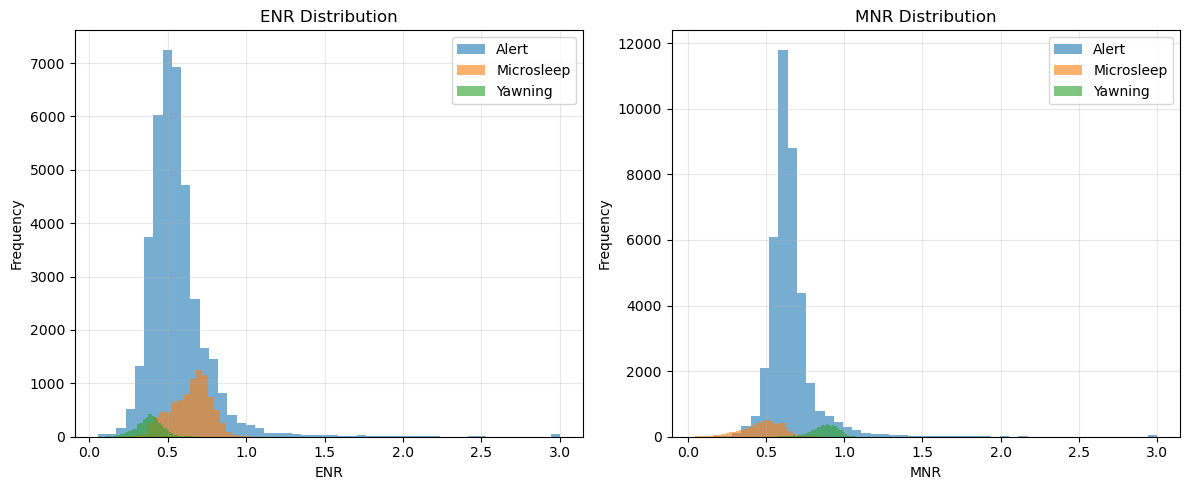

✅ Visualization saved!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ENR
for state in ['alert', 'microsleep', 'yawning']:
    data = df[df['driver_state'] == state]['ENR']
    axes[0].hist(data, bins=50, alpha=0.6, label=state.capitalize())
axes[0].set_xlabel('ENR')
axes[0].set_ylabel('Frequency')
axes[0].set_title('ENR Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MNR
for state in ['alert', 'microsleep', 'yawning']:
    data = df[df['driver_state'] == state]['MNR']
    axes[1].hist(data, bins=50, alpha=0.6, label=state.capitalize())
axes[1].set_xlabel('MNR')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MNR Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved!")

Feature Engineering

In [12]:
# حفظ المجموعات
train_df.to_pickle("train_df.pkl")
val_df.to_pickle("val_df.pkl")
test_df.to_pickle("test_df.pkl")

print("✅ Data saved successfully!")

✅ Data saved successfully!


In [14]:
import os

BASE_PATH = "/home/jovyan/myenvs/FBF"

def fix_image_path(img_path):
    if "classification_frames-level-driver-drowsiness-detection-fl3d/classification_frames/" in img_path:
        parts = img_path.split("classification_frames-level-driver-drowsiness-detection-fl3d/classification_frames/", 1)
        return os.path.join(BASE_PATH, "classification_frames", parts[1])
    if img_path.startswith("./classification_frames/"):
        relative_part = img_path[len("./classification_frames/"):]
        return os.path.join(BASE_PATH, "classification_frames", relative_part)
    if img_path.startswith("/home/jovyan/myenvs/FBF/classification_frames/"):
        return img_path
    return os.path.join(BASE_PATH, img_path.lstrip("./"))

# إضافة العمود إلى df العام
df['image_path_fixed'] = df['image_path'].apply(fix_image_path)
print("✅ تم إنشاء 'image_path_fixed' في df العام")

✅ تم إنشاء 'image_path_fixed' في df العام


In [14]:
import os

# ⚠️ تأكد من أن هذا المسار صحيح ويشير إلى مجلد FL3D
BASE_PATH = "/home/jovyan/myenvs/FBF/classification_frames"

def fix_image_path(img_path):
    """
    يحول المسار النسبي إلى مسار مطلق يُمكن قراءته بواسطة cv2.imread
    """
    if img_path.startswith("./classification_frames/"):
        relative_part = img_path[len("./classification_frames/"):]
        return os.path.join(BASE_PATH, "classification_frames", relative_part)
    
    elif "/home/jovyan/myenvs/FBF/classification_frames" in img_path:
        parts = img_path.split("/home/jovyan/myenvs/FBF/classification_frames", 1)
        return os.path.join(BASE_PATH, "classification_frames", parts[1])
    
    elif img_path.startswith(BASE_PATH):
        return img_path
    
    else:
        return os.path.join(BASE_PATH, img_path.lstrip("./"))

# إضافة العمود إلى df العام
df['image_path_fixed'] = df['image_path'].apply(fix_image_path)

# تطبيق نفس التصحيح على المجموعات بعد التقسيم
train_df['image_path_fixed'] = train_df['image_path'].apply(fix_image_path)
val_df['image_path_fixed'] = val_df['image_path'].apply(fix_image_path)
test_df['image_path_fixed'] = test_df['image_path'].apply(fix_image_path)

print("✅ تم إنشاء 'image_path_fixed' في جميع المجموعات")

✅ تم إنشاء 'image_path_fixed' في جميع المجموعات


In [16]:
for split_df in [train_df, val_df, test_df]:
    split_df['image_path_fixed'] = split_df['image_path'].apply(fix_image_path)


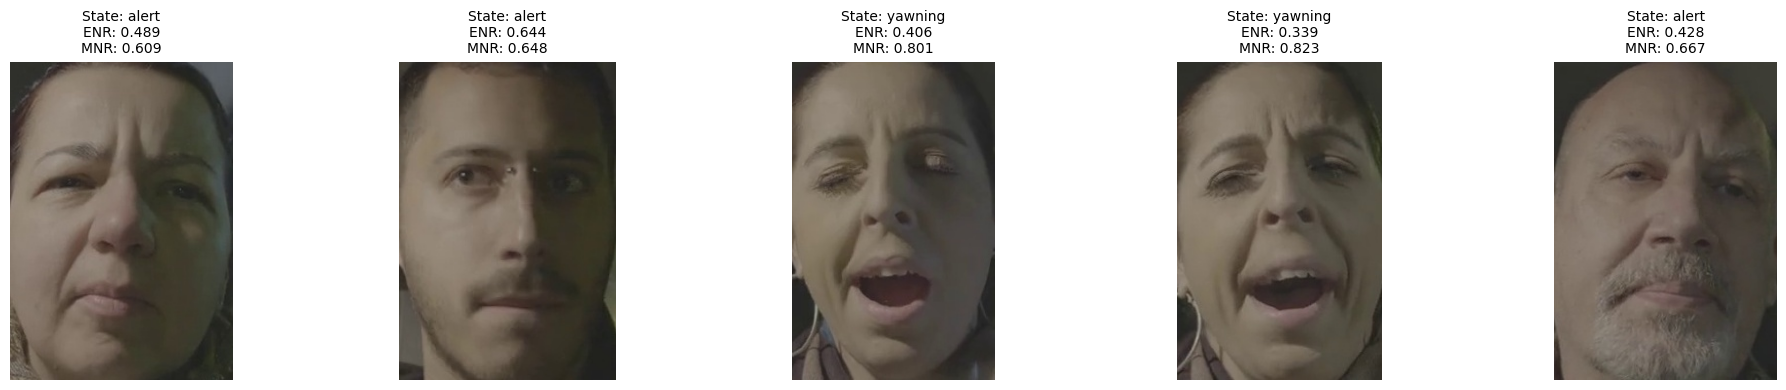

In [15]:
import cv2
import os
import matplotlib.pyplot as plt

def plot_sample_frames(df, n_samples=5):
    sample_df = df.sample(n=n_samples + 1, random_state=42).iloc[1:]
    plt.figure(figsize=(20, 4))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        # ❌ خطأ: img_path = row['image_path_fixed']
        # ✅ صحيح:
        img_path = row['image_path_fixed']  # ← العمود الصحيح
        
        if not os.path.exists(img_path):
            print(f"File not found: {img_path}")
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to load image: {img_path}")
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # ✅ غيّر الأسماء إلى ENR و MNR (لأنك لا تستخدم EAR/MAR)
        enr = row['ENR']
        mnr = row['MNR']
        state = row['driver_state']
        
        text = f"State: {state}\nENR: {enr:.3f}\nMNR: {mnr:.3f}"
        
        plt.subplot(1, n_samples, i+1)
        plt.imshow(img_rgb)
        plt.title(text, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run visualization
plot_sample_frames(df, n_samples=5)


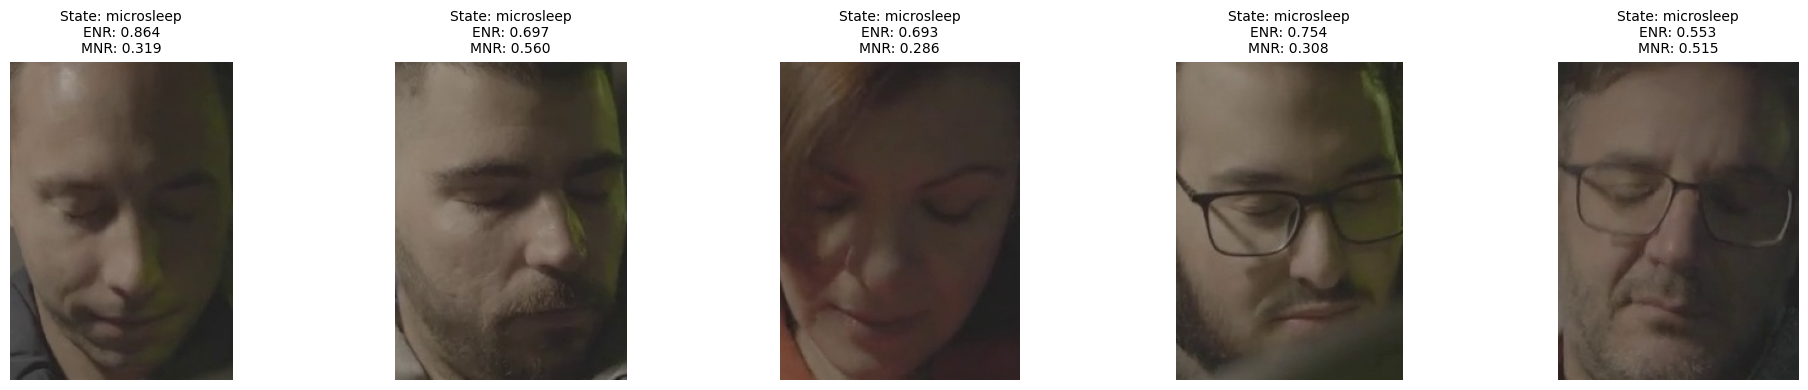

In [17]:
microsleep_df = df[df['driver_state'] == 'microsleep']
plot_sample_frames(microsleep_df, n_samples=5)

In [18]:
from collections import Counter
import numpy as np

label_to_idx = {"alert": 0, "microsleep": 1, "yawning": 2}

def build_sequences_from_df_fixed(df, seq_len=32, stride=8):
    sequences = []
    geo_features = []
    labels = []
    
    for vid, group in df.groupby("video_id"):
        group = group.sort_values("frame_num").reset_index(drop=True)
        if len(group) < seq_len:
            continue
            
        paths = group["image_path_fixed"].tolist()
        geo_data = group[["ENR", "MNR", "nose_angle", "eye_angle"]].values
        states = group["driver_state"].tolist()
        
        for start in range(0, len(group) - seq_len + 1, stride):
            end = start + seq_len
            
            seq_paths = paths[start:end]
            seq_geo = geo_data[start:end]
            majority_state = Counter(states[start:end]).most_common(1)[0][0]
            
            sequences.append(seq_paths)
            geo_features.append(seq_geo)
            labels.append(label_to_idx[majority_state])
    
    return sequences, np.array(geo_features), np.array(labels)

# البناء
train_seq_paths, train_seq_feats, train_seq_labels = build_sequences_from_df_fixed(train_df)
val_seq_paths, val_seq_feats, val_seq_labels = build_sequences_from_df_fixed(val_df)
test_seq_paths, test_seq_feats, test_seq_labels = build_sequences_from_df_fixed(test_df)

print("✅ تم البناء بنجاح!")


✅ تم البناء بنجاح!


In [19]:
# التحقق من أول مسار
print("المسار الأول في train_seq_paths:")
print(train_seq_paths[0][0])
print("الملف موجود:", os.path.exists(train_seq_paths[0][0]))

المسار الأول في train_seq_paths:
/home/jovyan/myenvs/FBF/classification_frames/P1042756_720/frame0.jpg
الملف موجود: True


In [25]:
np.save("train_seq_paths.npy", train_seq_paths, allow_pickle=True)
np.save("train_seq_feats.npy", train_seq_feats)
np.save("train_seq_labels.npy", train_seq_labels)

np.save("val_seq_paths.npy", val_seq_paths, allow_pickle=True)
np.save("val_seq_feats.npy", val_seq_feats)
np.save("val_seq_labels.npy", val_seq_labels)

np.save("test_seq_paths.npy", test_seq_paths, allow_pickle=True)
np.save("test_seq_feats.npy", test_seq_feats)
np.save("test_seq_labels.npy", test_seq_labels)
